In [30]:
import numpy as np

import matplotlib.pyplot as plt

In [31]:
class ContinuousSignal:

    def __init__(self, func):
        self.func = func
    def shift(self, shift):
        return ContinuousSignal(lambda t: self.func(t - shift))
    def add(self, other):
        return ContinuousSignal(lambda t: self.func(t) + other.func(t))
    def multiply(self, other):
        return ContinuousSignal(lambda t: self.func(t) * other.func(t))
    def multiply_const_factor(self, scaler):
        return ContinuousSignal(lambda t: scaler * self.func(t))
    
    def plot(self, t_min, t_max, num_points, title=""):
        t = np.linspace(t_min, t_max, num_points)
        x = self.func(t)

        plt.figure()
        plt.plot(t, x)
        plt.xlabel("t")
        plt.ylabel("Amplitude")
        plt.title(title)
        plt.grid(True)

        plt.show()



In [32]:
class LTIContinuous:
    def __init__(self, impulse_response):
        
        self.impulse_response = impulse_response

    def linear_combination_of_impulses(self, input_signal, delta,t_min=-3, t_max=3):
        tks = np.arange(t_min, t_max, delta)
        impulses = []
        coefficients = []

        for tk in tks:
            ck = input_signal.func(np.array([tk]))[0] * delta

            def rect_impulse(t, tk=tk, delta=delta):
                return np.where(
                    (t >= tk) & (t < tk + delta),
                    1.0 / delta,
                    0.0
                )

            impulses.append(ContinuousSignal(rect_impulse))
            coefficients.append(ck)

        return impulses, coefficients

    def output_approx(self, input_signal, delta):
        raise NotImplementedError

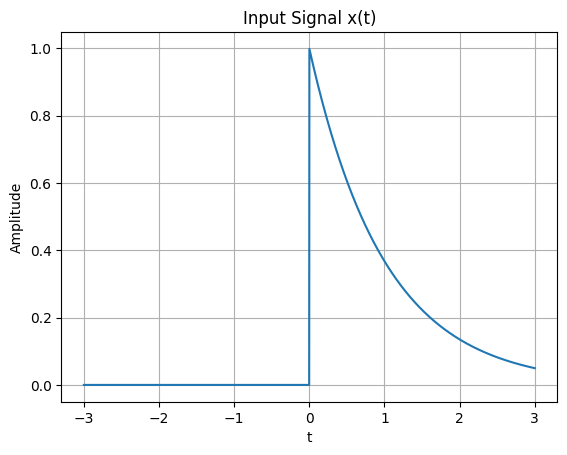

In [40]:
T = 3
num_points = 2000


u = lambda t: np.where(t >= 0, 1.0, 0.0)

x = ContinuousSignal(lambda t: np.exp(-t) * u(t))
h = ContinuousSignal(lambda t: u(t))

system = LTIContinuous(h)


x.plot(
    -T, T, num_points,
    title="Input Signal x(t)",
    
)



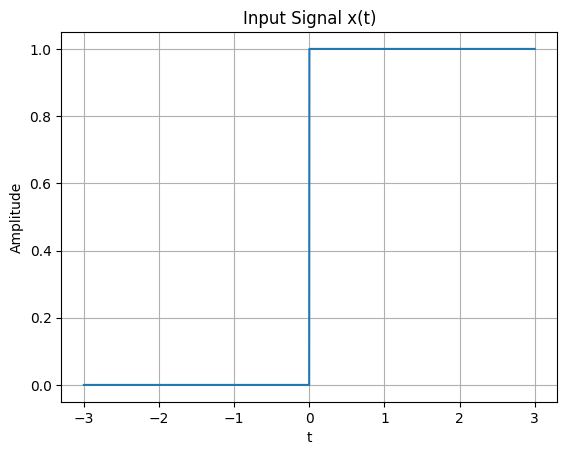

In [41]:

h.plot(
    -T, T, num_points,
    title="Input Signal x(t)",
    
)

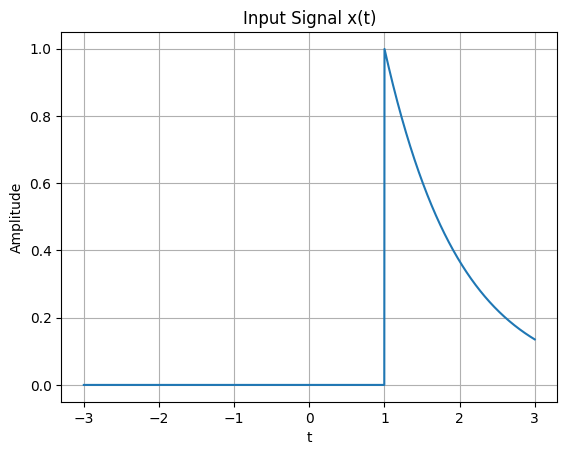

In [ ]:
x=x.shift(1)
x.plot(
    -T, T, num_points,
    title="Input Signal x(t)",
    
)

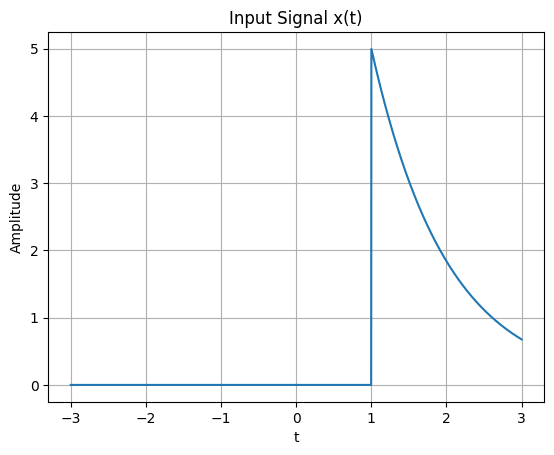

In [43]:
x=x.multiply_const_factor(5)
x.plot(
    -T, T, num_points,
    title="Input Signal x(t)",
    
)

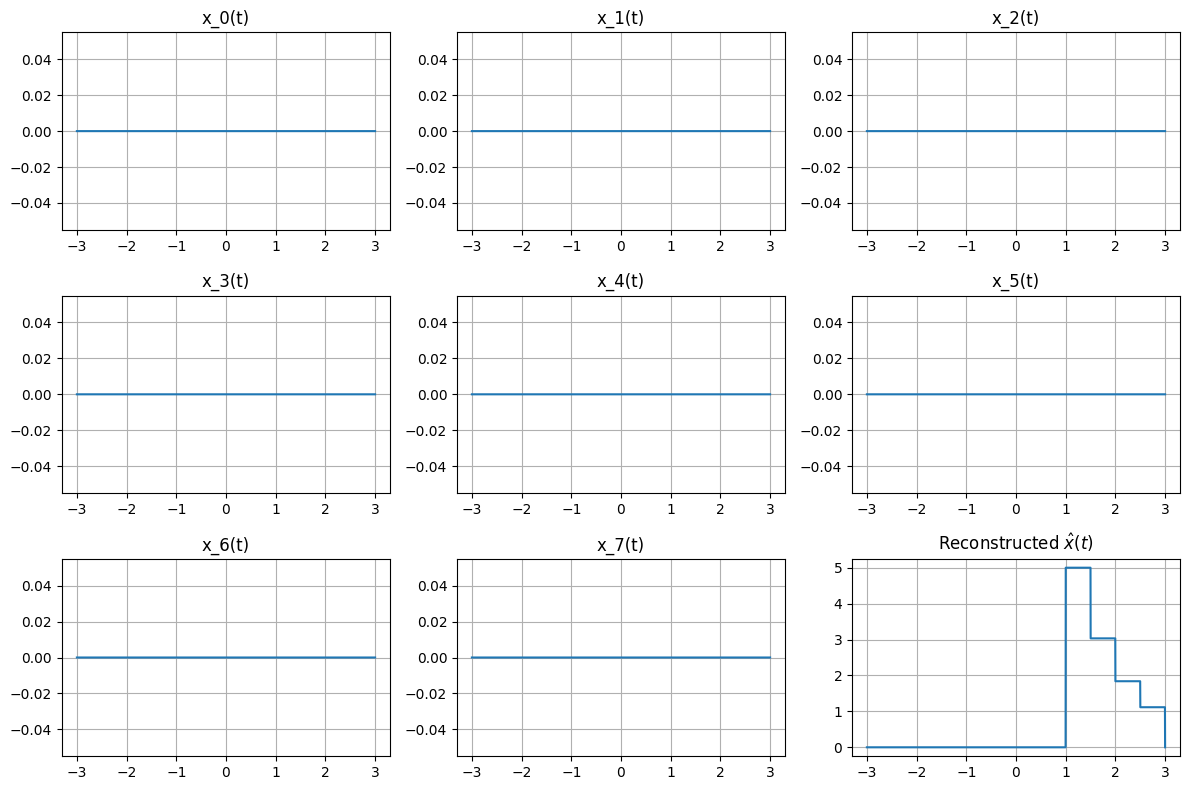

In [44]:
#Decompose

delta = 0.5
impulses, coefficients = system.linear_combination_of_impulses(
    x, delta, -T, T
)

# Build component signals
components = [
    impulses[k].multiply_const_factor(coefficients[k])
    for k in range(len(impulses))
]

# Reconstruct x_hat
x_hat = components[0]
for comp in components[1:]:
    x_hat = x_hat.add(comp)

t = np.linspace(-T, T, num_points)

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(8):
    axes[i].plot(t, components[i].func(t))
    axes[i].set_title(f"x_{i}(t)")
    axes[i].grid(True)

axes[8].plot(t, x_hat.func(t))
axes[8].set_title("Reconstructed $\hat{x}(t)$")
axes[8].grid(True)

plt.tight_layout()

plt.show()
